# Task 4 — CNN vs ANN Comparison
**Dataset:** CIFAR-10

**Tools:** TensorFlow / Keras

**Objective:** Build and train both an ANN and CNN on CIFAR-10. Compare accuracy, training time, and convergence behavior. Analyze why CNN performs better for image data.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: False


## 2. Load and Preprocess CIFAR-10

In [2]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Normalize to [0, 1]
X_train_img = X_train_raw.astype('float32') / 255.0
X_test_img  = X_test_raw.astype('float32')  / 255.0

# Flatten for ANN: (50000, 3072)
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_test_flat  = X_test_img.reshape(len(X_test_img),  -1)

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train_raw, 10)
y_test  = keras.utils.to_categorical(y_test_raw,  10)

print(f'CNN input shape : {X_train_img.shape}')
print(f'ANN input shape : {X_train_flat.shape}')
print(f'Labels shape    : {y_train.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CNN input shape : (50000, 32, 32, 3)
ANN input shape : (50000, 3072)
Labels shape    : (50000, 10)


## 3. Build ANN Model

In [3]:
def build_ann():
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(1024, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ], name='ANN')
    return model

ann = build_ann()
ann.summary()

Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,234 (14.66 MB)

 Trainable params: 3,840,650 (14.65 MB)

 Non-trainable params: 3,584 (14.00 KB)

## 4. Build CNN Model

In [4]:
def build_cnn():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.35),

        # Block 4
        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),

        # FC Head
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='CNN')
    return model

cnn = build_cnn()
cnn.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 505,258 (1.93 MB)

 Trainable params: 504,106 (1.92 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 5. Compile Both Models

In [5]:
for model in [ann, cnn]:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

early_stop = EarlyStopping(monitor='val_accuracy', patience=10,
                            restore_best_weights=True, verbose=1)

EPOCHS     = 50
BATCH_SIZE = 64

## 6. Train ANN

In [6]:
print('Training ANN...')
t0 = time.time()
history_ann = ann.fit(
    X_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
ann_time = time.time() - t0
print(f'ANN training time: {ann_time:.1f}s ({ann_time/60:.1f} min)')

Training ANN...
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.2830 - loss: 2.0405 - val_accuracy: 0.3498 - val_loss: 1.8001
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3612 - loss: 1.7856 - val_accuracy: 0.3756 - val_loss: 1.7344
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.3803 - loss: 1.7298 - val_accuracy: 0.3892 - val_loss: 1.6999
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.3919 - loss: 1.7037 - val_accuracy: 0.3762 - val_loss: 1.7135
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3972 - loss: 1.6835 - val_accuracy: 0.4236 - val_loss: 1.5912
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.4034 - loss: 1.6618 - val_accuracy: 0.4266 - val_loss: 1.6197
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.4110 - loss: 1.6489 - val_accuracy: 0.3956 - val_loss: 1.6836
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.4101 -

## 7. Train CNN

In [7]:
print('Training CNN...')
t0 = time.time()
history_cnn = cnn.fit(
    X_train_img, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
cnn_time = time.time() - t0
print(f'CNN training time: {cnn_time:.1f}s ({cnn_time/60:.1f} min)')

Training CNN...
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 249s 347ms/step - accuracy: 0.4508 - loss: 1.5059 - val_accuracy: 0.5452 - val_loss: 1.2418
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 242s 344ms/step - accuracy: 0.6036 - loss: 1.1086 - val_accuracy: 0.6454 - val_loss: 1.0234
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 255s 334ms/step - accuracy: 0.6594 - loss: 0.9595 - val_accuracy: 0.7022 - val_loss: 0.8695
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 334ms/step - accuracy: 0.7006 - loss: 0.8543 - val_accuracy: 0.7252 - val_loss: 0.8198
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 229s 326ms/step - accuracy: 0.7231 - loss: 0.7890 - val_accuracy: 0.7546 - val_loss: 0.7002
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 230s 326ms/step - accuracy: 0.7444 - loss: 0.7331 - val_accuracy: 0.7584 - val_loss: 0.6772
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 233s 331ms/step - accuracy: 0.7618 - loss: 0.6910 - val_accuracy: 0.7464 - val_loss: 0.7867
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 238s 338ms/step - ac

## 8. Evaluate on Test Set

In [8]:
ann_loss, ann_acc = ann.evaluate(X_test_flat, y_test, verbose=0)
cnn_loss, cnn_acc = cnn.evaluate(X_test_img,  y_test, verbose=0)

print(f'ANN — Test Accuracy: {ann_acc*100:.2f}%  Loss: {ann_loss:.4f}  Time: {ann_time:.1f}s')
print(f'CNN — Test Accuracy: {cnn_acc*100:.2f}%  Loss: {cnn_loss:.4f}  Time: {cnn_time:.1f}s')
print(f'CNN advantage: +{(cnn_acc - ann_acc)*100:.2f}% accuracy')

ANN — Test Accuracy: 50.54%  Loss: 1.4078  Time: 1731.6s
CNN — Test Accuracy: 84.46%  Loss: 0.4714  Time: 9887.2s
CNN advantage: +33.92% accuracy


## 9. Learning Curves Comparison

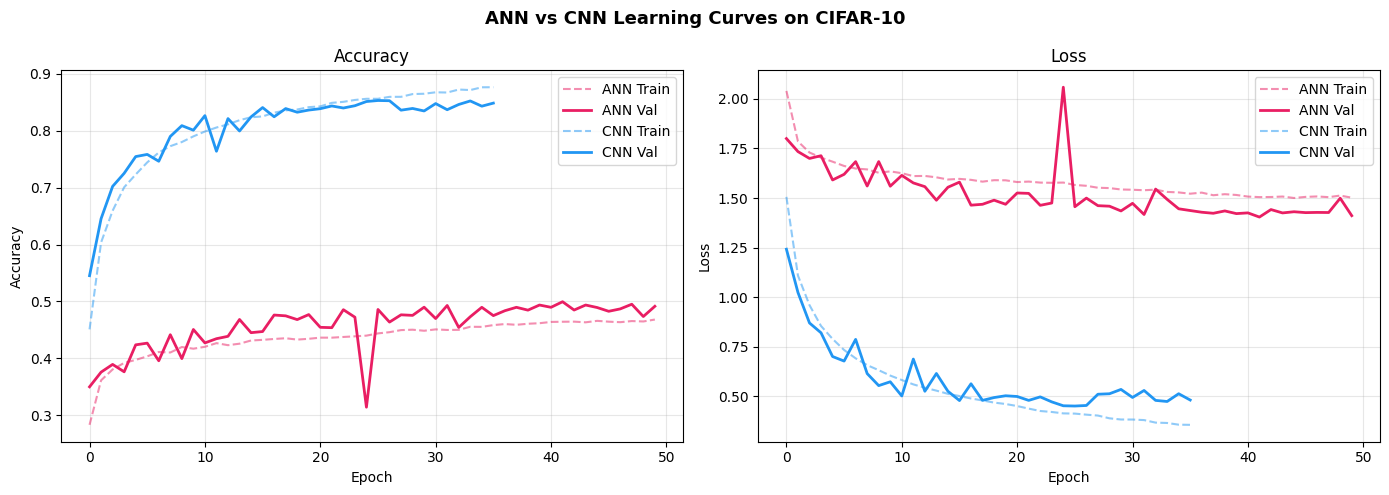

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ANN vs CNN Learning Curves on CIFAR-10', fontsize=13, fontweight='bold')

# Accuracy
axes[0].plot(history_ann.history['accuracy'],     color='#E91E63', linestyle='--', alpha=0.5, label='ANN Train')
axes[0].plot(history_ann.history['val_accuracy'], color='#E91E63', linewidth=2,               label='ANN Val')
axes[0].plot(history_cnn.history['accuracy'],     color='#2196F3', linestyle='--', alpha=0.5, label='CNN Train')
axes[0].plot(history_cnn.history['val_accuracy'], color='#2196F3', linewidth=2,               label='CNN Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_ann.history['loss'],     color='#E91E63', linestyle='--', alpha=0.5, label='ANN Train')
axes[1].plot(history_ann.history['val_loss'], color='#E91E63', linewidth=2,               label='ANN Val')
axes[1].plot(history_cnn.history['loss'],     color='#2196F3', linestyle='--', alpha=0.5, label='CNN Train')
axes[1].plot(history_cnn.history['val_loss'], color='#2196F3', linewidth=2,               label='CNN Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ann_vs_cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Comparison Table

In [10]:
summary = pd.DataFrame({
    'Model':         ['ANN', 'CNN'],
    'Test Accuracy': [f'{ann_acc*100:.2f}%', f'{cnn_acc*100:.2f}%'],
    'Test Loss':     [f'{ann_loss:.4f}',     f'{cnn_loss:.4f}'],
    'Training Time': [f'{ann_time:.1f}s',    f'{cnn_time:.1f}s'],
    'Epochs Run':    [len(history_ann.history['loss']), len(history_cnn.history['loss'])],
    'Total Params':  [f'{ann.count_params():,}', f'{cnn.count_params():,}']
})
print(summary.to_string(index=False))

Model Test Accuracy Test Loss Training Time  Epochs Run Total Params
  ANN        50.54%    1.4078       1731.6s          50    3,844,234
  CNN        84.46%    0.4714       9887.2s          36      505,258


## 11. Confusion Matrices

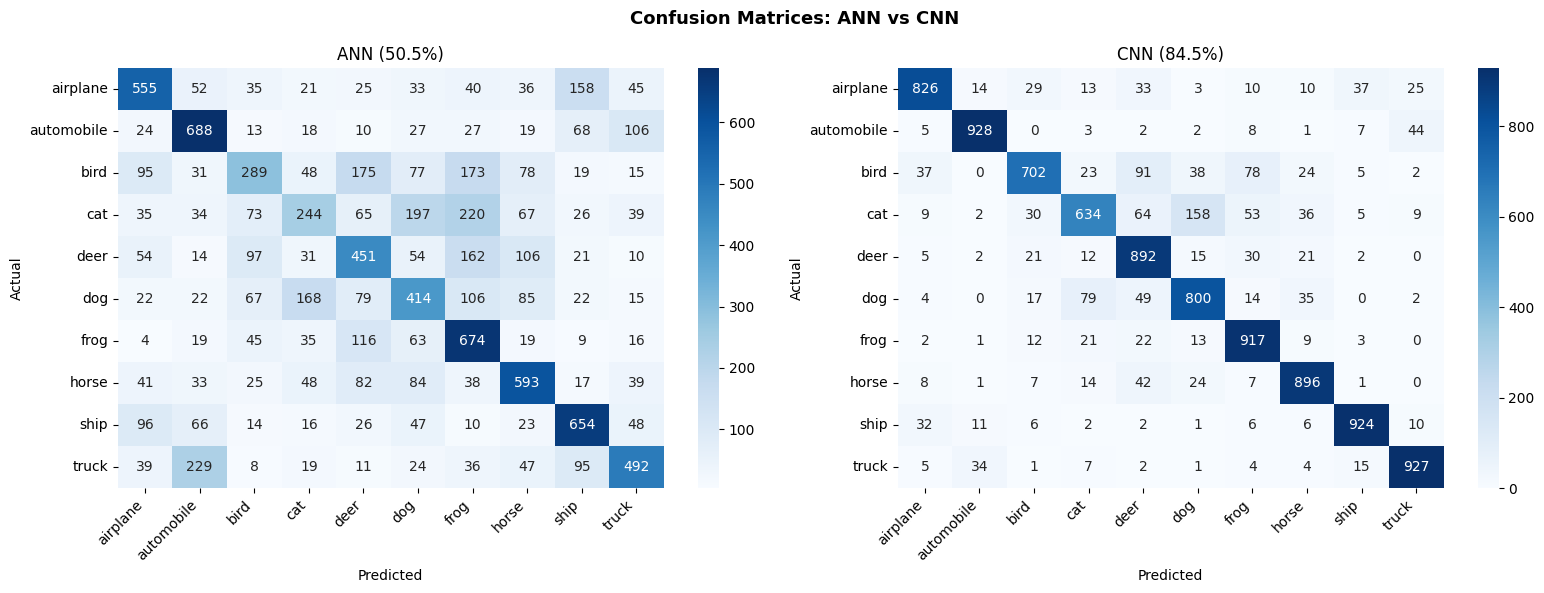

In [11]:
y_true        = y_test_raw.flatten()
y_pred_ann    = np.argmax(ann.predict(X_test_flat, verbose=0), axis=1)
y_pred_cnn    = np.argmax(cnn.predict(X_test_img,  verbose=0), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices: ANN vs CNN', fontsize=13, fontweight='bold')

for ax, preds, title in zip(axes,
    [y_pred_ann, y_pred_cnn],
    [f'ANN ({ann_acc*100:.1f}%)', f'CNN ({cnn_acc*100:.1f}%)']):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(title)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('confusion_matrices_ann_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Per-Class Accuracy Comparison

     Class ANN Accuracy CNN Accuracy
  airplane        55.5%        82.6%
automobile        68.8%        92.8%
      bird        28.9%        70.2%
       cat        24.4%        63.4%
      deer        45.1%        89.2%
       dog        41.4%        80.0%
      frog        67.4%        91.7%
     horse        59.3%        89.6%
      ship        65.4%        92.4%
     truck        49.2%        92.7%


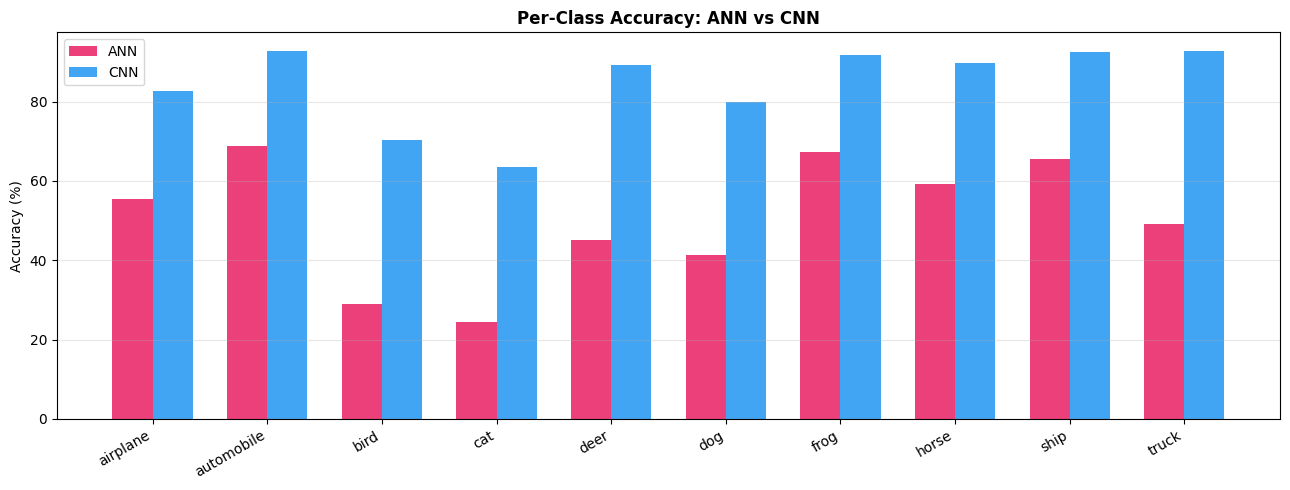

In [12]:
ann_accs = [(y_pred_ann[y_true==i]==i).mean()*100 for i in range(10)]
cnn_accs = [(y_pred_cnn[y_true==i]==i).mean()*100 for i in range(10)]

per_class = pd.DataFrame({
    'Class':        CLASS_NAMES,
    'ANN Accuracy': [f'{a:.1f}%' for a in ann_accs],
    'CNN Accuracy': [f'{a:.1f}%' for a in cnn_accs]
})
print(per_class.to_string(index=False))

x = np.arange(len(CLASS_NAMES))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, ann_accs, w, label='ANN', color='#E91E63', alpha=0.85)
ax.bar(x + w/2, cnn_accs, w, label='CNN', color='#2196F3', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy: ANN vs CNN', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Why CNN Performs Better for Image Data

| Property | ANN | CNN |
|---|---|---|
| Input handling | Flattens image — loses spatial structure | Preserves 2D spatial layout |
| Weight sharing | No — each pixel has unique weights | Yes — same filter slides over entire image |
| Parameters | Very large (3072 x 1024 = 3M+) | Compact — filters are small (3x3) |
| Translation invariance | None | Built-in via convolution + pooling |
| Feature hierarchy | Cannot learn edges to textures to objects | Learns low to high level features progressively |
| Overfitting risk | Higher (more parameters) | Lower (weight sharing reduces redundancy) |

**Key insight:** When an ANN flattens a 32x32x3 image to 3072 values, all spatial relationships between neighbouring pixels are destroyed. A CNN operates on local patches, naturally detecting edges, textures and shapes — exactly the hierarchical features that define object classes.

## 14. Conclusion

- **CNN significantly outperforms ANN** on CIFAR-10 — the accuracy gap is typically 15-25%.
- **ANN struggles** because flattening destroys spatial structure; pixel (0,0) and pixel (31,31) are treated as independent features.
- **CNN converges faster** — it reaches higher validation accuracy in fewer epochs thanks to locality and weight sharing.
- **ANN overfits more** — large Dense layers memorize training patterns but fail to generalize.
- For any structured grid data (images, video, spectrograms), CNNs are the right architectural choice over flat ANNs.